# Cancer-Expert Final Evaluation

This notebook compares the official Baseline ResNet50, the Basemodel small CNN, and Cancer-Expert on the PathMNIST test split. Cancer-Expert is the Basemodel plus the Debris-Stroma, Smooth-Muscle-Stroma, and Epithelium-Stroma expert correction models.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd


## Test Model Comparison

The merged cancer metric treats cancer-associated stroma (`7`) and colorectal adenocarcinoma epithelium (`8`) as one positive class against all other tissue classes. AUC is intentionally omitted because Cancer-Expert produces hard corrected labels rather than a calibrated multiclass probability distribution.


In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, fbeta_score, recall_score

RESNET50_PRED_PATH = Path('../results/baseline_resnet50/test_predictions.csv')
BASEMODEL_PRED_PATH = Path('../results/basemodel/test_predictions.npz')
EXPERT_PRED_PATH = Path('../results/cancer_expert/pair_test_targeted_predictions.npz')

STROMA_LABEL = 7
EPITHELIUM_LABEL = 8
N_CLASSES = 9


def load_resnet50_predictions(expected_y_true):
    frame = pd.read_csv(RESNET50_PRED_PATH)
    if not np.array_equal(frame['y_true'].to_numpy(dtype=int), expected_y_true):
        raise ValueError('ResNet50 predictions do not align with Basemodel labels')
    prob_columns = [column for column in frame.columns if column.startswith('prob_')]
    return frame['y_pred'].to_numpy(dtype=int), frame[prob_columns].to_numpy(dtype=float)


def adjusted_probabilities_from_labels(base_prob, corrected_pred):
    adjusted = base_prob.copy()
    base_pred = base_prob.argmax(axis=1)
    changed = corrected_pred != base_pred
    if np.any(changed):
        rows = np.where(changed)[0]
        adjusted[rows, corrected_pred[rows]] = adjusted[rows].max(axis=1) + 1e-6
        adjusted = adjusted / adjusted.sum(axis=1, keepdims=True)
    return adjusted


def metric_row(system, y_true, y_pred, y_prob):
    merged_true = np.isin(y_true, [STROMA_LABEL, EPITHELIUM_LABEL])
    merged_pred = np.isin(y_pred, [STROMA_LABEL, EPITHELIUM_LABEL])
    stroma_true = y_true == STROMA_LABEL
    stroma_pred = y_pred == STROMA_LABEL
    epithelium_true = y_true == EPITHELIUM_LABEL
    epithelium_pred = y_pred == EPITHELIUM_LABEL
    return {
        'System': system,
        'ACC': accuracy_score(y_true, y_pred),
        'Overall recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall stroma+epithelium vs rest': recall_score(merged_true, merged_pred, zero_division=0),
        'Recall stroma': recall_score(stroma_true, stroma_pred, zero_division=0),
        'Recall epithelium': recall_score(epithelium_true, epithelium_pred, zero_division=0),
        'F2 stroma+epithelium vs rest': fbeta_score(
            merged_true,
            merged_pred,
            beta=2,
            zero_division=0,
        ),
        'F2 stroma': fbeta_score(stroma_true, stroma_pred, beta=2, zero_division=0),
        'F2 epithelium': fbeta_score(epithelium_true, epithelium_pred, beta=2, zero_division=0),
    }

basemodel = np.load(BASEMODEL_PRED_PATH)
y_true = basemodel['y_true'].reshape(-1).astype(int)
basemodel_prob = basemodel['y_prob']
basemodel_pred = basemodel_prob.argmax(axis=1)

resnet50_pred, resnet50_prob = load_resnet50_predictions(y_true)

expert = np.load(EXPERT_PRED_PATH)
expert_pred = expert['y_pred'].reshape(-1).astype(int)
expert_prob = adjusted_probabilities_from_labels(basemodel_prob, expert_pred)

comparison = pd.DataFrame([
    metric_row('Baseline ResNet50', y_true, resnet50_pred, resnet50_prob),
    metric_row('Basemodel', y_true, basemodel_pred, basemodel_prob),
    metric_row('Cancer-Expert', y_true, expert_pred, expert_prob),
])

comparison.style.format({
    'ACC': '{:.4f}',
    'Overall recall (macro)': '{:.4f}',
    'Recall stroma+epithelium vs rest': '{:.4f}',
    'Recall stroma': '{:.4f}',
    'Recall epithelium': '{:.4f}',
    'F2 stroma+epithelium vs rest': '{:.4f}',
    'F2 stroma': '{:.4f}',
    'F2 epithelium': '{:.4f}',
})

,System,ACC,Overall recall (macro),Recall stroma+epithelium vs rest,Recall stroma,Recall epithelium,F2 stroma+epithelium vs rest,F2 stroma,F2 epithelium
0,Baseline ResNet50,0.9238,0.8981,0.8888,0.5439,0.9667,0.9029,0.5917,0.9605
1,Basemodel,0.9057,0.8886,0.9160,0.5202,0.9886,0.9172,0.5688,0.9623
2,Cancer-Expert,0.9259,0.9295,0.9800,0.9311,0.9830,0.9652,0.9087,0.9712


### Comparison Bar Chart

The grouped bar chart visualizes the same test-set metrics for the three final systems.


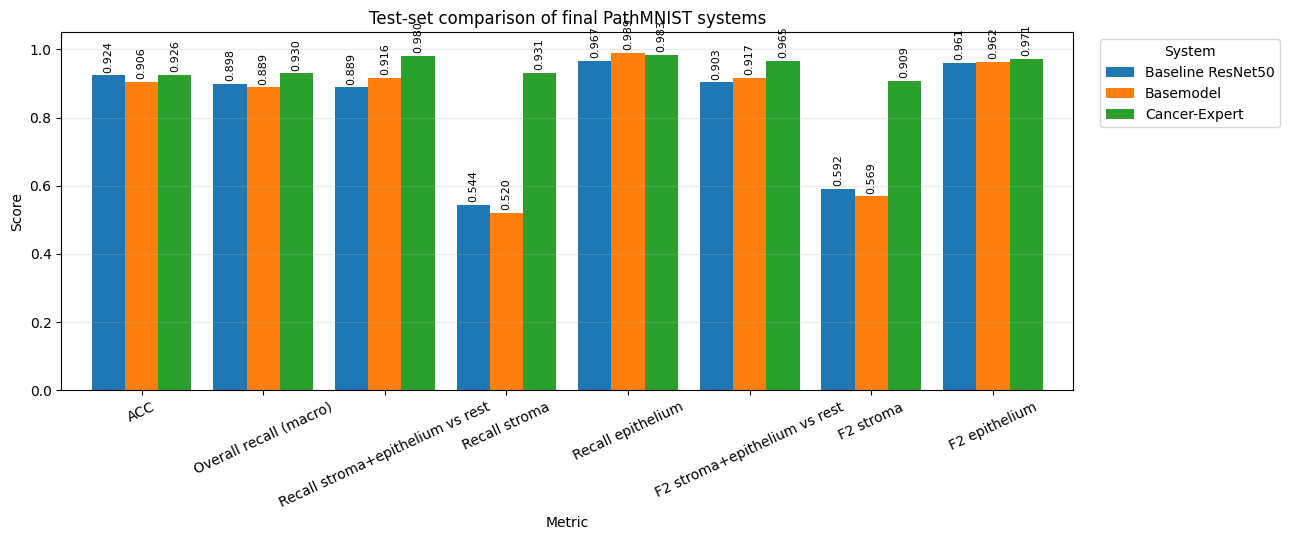

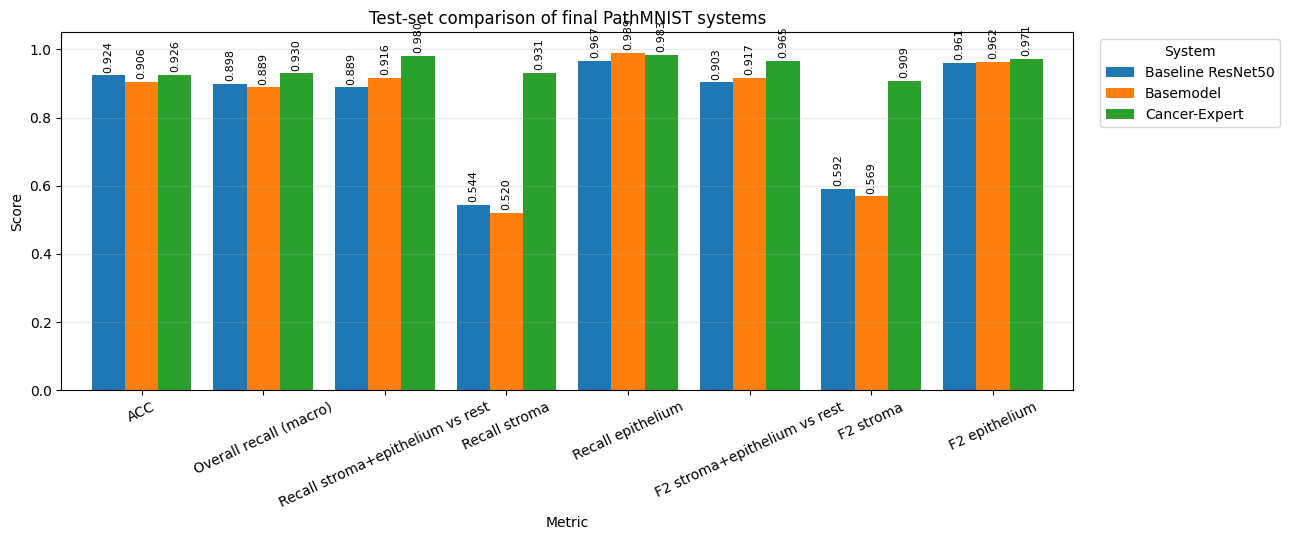

In [3]:
metric_columns = [
    'ACC',
    'Overall recall (macro)',
    'Recall stroma+epithelium vs rest',
    'Recall stroma',
    'Recall epithelium',
    'F2 stroma+epithelium vs rest',
    'F2 stroma',
    'F2 epithelium',
]

plot_df = comparison.set_index('System')[metric_columns].T
ax = plot_df.plot(kind='bar', figsize=(13, 5.5), width=0.82)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.set_title('Test-set comparison of final PathMNIST systems')
ax.legend(title='System', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.25)
ax.tick_params(axis='x', rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2, rotation=90)

plt.tight_layout()
ax.figure